# Tapered square tube -- RM shell vs 3-D solid

Homogenizes the equivalent-beam **Timoshenko $6\times6$** ($C^b$) of the tapered square tube
with a single **6-DOF independent-$\omega_3$ Reissner--Mindlin shell**, for both the
**boundary ring** and the **tapered segment**, at thin ($t/R=0.02$) and thick ($t/R=0.20$)
walls, single $[-45^\circ]$ ply, and compares against a conforming 3-D FEniCS solid.

A flat-walled tube ($k_{22}=0$ on the faces) -- the case that exposes the drilling degeneracy MITC would alias.

Transverse-shear scheme (6-DOF everywhere): the tapered segment uses **full integration** at
every thickness (locking-free; MITC would alias the drilling on flat walls); the boundary ring
uses a $\gamma_{23}$-tie on the thin wall and full integration on the thick wall.

This notebook runs `examples/RM_taper/square.py` inline.

In [1]:
%matplotlib inline
import os, sys, numpy as np
def _root(d):
    d = os.path.abspath(d)
    while d != os.path.dirname(d):
        if os.path.exists(os.path.join(d, "pyproject.toml")): return d
        d = os.path.dirname(d)
    return os.getcwd()
CC = _root(os.getcwd())
sys.path.insert(0, os.path.join(CC, "examples", "RM_taper"))
sys.path.insert(0, os.path.join(CC, "opensg_jax"))
import _rm_common as rm
np.set_printoptions(precision=4, suppress=True, linewidth=140)
MESH = os.path.join(CC, "examples", "data", "taper_square", "meshes")
REF  = np.load(os.path.join(CC, "examples", "data", "benchmark", "taper_square_solid_m45.npz"))
RES  = os.path.join(CC, "docs", "tutorials", "_rmout"); os.makedirs(RES, exist_ok=True)

## Mesh and material orientation

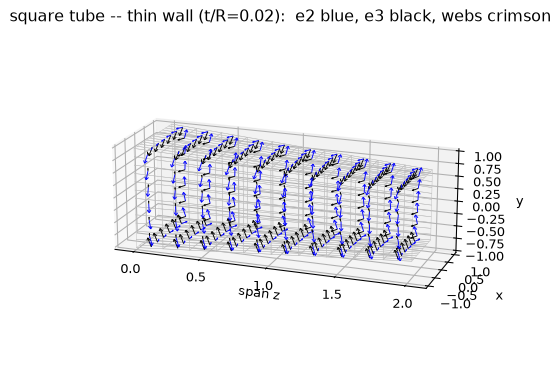

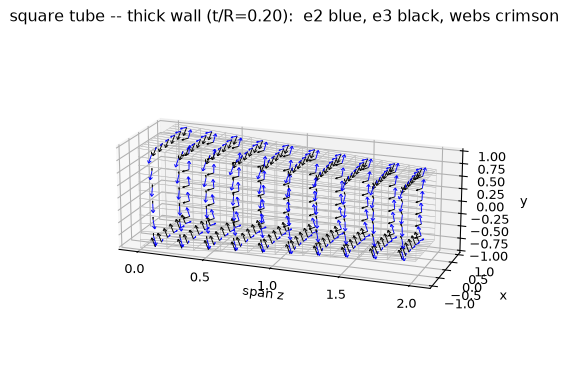

In [2]:
from IPython.display import Image, display
for r in ("thin", "thick"):
    tg = "{r}_m45_aR070".replace("{r}", r)
    ttl = "square tube -- %s wall (t/R=%s):  e2 blue, e3 black, webs crimson" % (r, "0.02" if r == "thin" else "0.20")
    png = rm.render_orientation(MESH, tg, RES, title=ttl)
    display(Image(filename=png))

## Timoshenko $6\times6$ -- boundary ring and tapered segment

In [3]:
def show(label, So, Sh, shear):
    So = 0.5 * (So + So.T); Sh = 0.5 * (Sh + Sh.T)
    print("\n" + label + "   [6-DOF RM shell, shear=%s]" % shear)
    print("RM shell Timoshenko 6x6  (x1e9):")
    print(Sh / 1e9)
    e = 100 * (np.diag(Sh) - np.diag(So)) / np.diag(So)
    print("diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]:", np.round(e, 1))

for r, tR in (("thin", 0.02), ("thick", 0.20)):
    tg = "{r}_m45_aR070".replace("{r}", r)
    print("=" * 72)
    print("square tube -- %s wall (t/R = %.2f)" % (r.upper(), tR))
    sb = rm.shear_for("boundary", tR); st = rm.shear_for("taper", tR)
    Cb = rm.solve_boundary(MESH, tg, RES, sb); show("BOUNDARY ring", REF[tg + "_L"], Cb, sb)
    Ct = rm.solve_taper(MESH, tg, RES, st);    show("TAPERED segment", REF[tg + "_seg"], Ct, st)

square tube -- THIN wall (t/R = 0.02)



BOUNDARY ring   [6-DOF RM shell, shear=mitc4_g23]
RM shell Timoshenko 6x6  (x1e9):
[[ 1.9625  0.      0.     -0.5345  0.      0.    ]
 [ 0.      0.493   0.     -0.      0.2778  0.    ]
 [ 0.      0.      0.493  -0.     -0.      0.2778]
 [-0.5345 -0.     -0.      1.1824 -0.     -0.    ]
 [ 0.      0.2778 -0.     -0.      1.3054 -0.    ]
 [ 0.      0.      0.2778 -0.     -0.      1.3054]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [0.8 1.5 1.5 1.4 0.5 0.5]



TAPERED segment   [6-DOF RM shell, shear=full]
RM shell Timoshenko 6x6  (x1e9):
[[ 1.5632  0.      0.     -0.3352 -0.     -0.    ]
 [ 0.      0.3345 -0.     -0.      0.1656 -0.0632]
 [ 0.     -0.      0.3345 -0.      0.0632  0.1656]
 [-0.3352 -0.     -0.      0.6586  0.      0.    ]
 [-0.      0.1656  0.0632  0.      0.7641 -0.    ]
 [-0.     -0.0632  0.1656  0.     -0.      0.7641]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [ 1.3 -1.7 -1.7 -4.4  2.3  2.3]
square tube -- THICK wall (t/R = 0.20)



BOUNDARY ring   [6-DOF RM shell, shear=full]
RM shell Timoshenko 6x6  (x1e9):
[[19.6248 -0.     -0.     -5.3453 -0.     -0.    ]
 [-0.      4.9758 -0.      0.      2.7939 -0.    ]
 [-0.     -0.      4.9758  0.      0.      2.7939]
 [-5.3453  0.      0.     12.0207 -0.      0.    ]
 [-0.      2.7939  0.     -0.     13.0943  0.    ]
 [-0.     -0.      2.7939  0.      0.     13.0943]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [ 0.8 -1.8 -1.8 -0.2 -0.3 -0.3]



TAPERED segment   [6-DOF RM shell, shear=full]
RM shell Timoshenko 6x6  (x1e9):
[[15.6338  0.     -0.     -3.347   0.     -0.    ]
 [ 0.      3.6683  0.     -0.      1.8082 -0.6922]
 [-0.      0.      3.6683 -0.      0.6922  1.8082]
 [-3.347  -0.     -0.      6.7394 -0.      0.    ]
 [ 0.      1.8082  0.6922 -0.      7.7518  0.    ]
 [-0.     -0.6922  1.8082  0.      0.      7.7518]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [ 0.8  1.9  1.9 -6.1  1.7  1.7]
